# PAWC in ten minutes**Partial** optimal transport on the **circle**, for **every** transported mass at once.Two measures on a circle rarely describe the same thing: one may be occluded, the othercluttered with mass that belongs to nothing.  A *partial* cost matches only part of themand leaves the rest alone.  The amount to match is rarely known in advance, so the usefulobject is not one number but the whole **profile** $k \mapsto C_k^\circ$ — the optimalcost of matching exactly $k$ pairs, for every $k$.PAWC returns that entire profile in one $O(N\log N)$ sweep.  This notebook shows what itreturns, what the pieces mean, and when partial transport is worth the trouble.Run it top to bottom; it takes a few seconds and needs only what `requirements.txt`installs.

In [1]:
import numpy as npimport matplotlib.pyplot as pltfrom pawc.pawc import partial_ot_circlerng = np.random.default_rng(0)plt.rcParams.update({"figure.dpi": 110, "font.size": 9,                     "axes.spines.top": False, "axes.spines.right": False})

## 1. The problemPoints live on a circle of circumference `L`, so position is periodic: on `L = 12`, thepoints `11.4` and `0.4` are `1.0` apart, not `11.0`.  That is the whole reason a circleneeds its own solver.We use the paper's worked example: four sources, four targets.

the wrap-around gap y[3]=11.4 -> x[0]=0.4 is 1.0 long, not 11.0


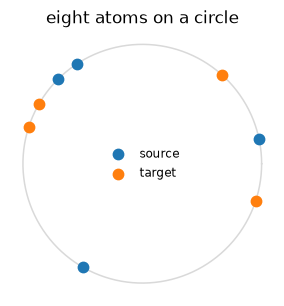

In [2]:
L = 12.0x = np.array([0.4, 4.1, 4.5, 8.0])      # sourcesy = np.array([1.6, 5.0, 5.4, 11.4])     # targetsdef draw_circle(ax, L, x, y, title=""):    t = np.linspace(0, 2 * np.pi, 400)    ax.plot(np.cos(t), np.sin(t), color="0.85", lw=1)    for pts, c, lab in ((x, "tab:blue", "source"), (y, "tab:orange", "target")):        a = 2 * np.pi * np.asarray(pts) / L        ax.scatter(np.cos(a), np.sin(a), s=45, color=c, zorder=3, label=lab)    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title)fig, ax = plt.subplots(figsize=(3.1, 3.1))draw_circle(ax, L, x, y, "eight atoms on a circle")ax.legend(loc="center", frameon=False, fontsize=8)print(f"the wrap-around gap y[3]={y[3]} -> x[0]={x[0]} is "      f"{min(abs(y[3]-x[0]), L-abs(y[3]-x[0]))} long, not {abs(y[3]-x[0])}")

## 2. One call answers every $k$`partial_ot_circle` returns a solution object holding the profile, the active sets, theplans on demand, and a cut we come back to in §5.

In [3]:
sol = partial_ot_circle(x, y, L=L, w=1.0)print("C_k for k = 0..K :", np.round(sol.costs, 3))print("K                :", len(sol.costs) - 1)print("solver           :", sol.solver)

C_k for k = 0..K : [0.  0.5 1.5 2.8 6.4]
K                : 4
solver           : pawc


`sol.costs[k]` is the **total** cost of moving $k$ atoms, so `sol.costs[k] / k` is theaverage distance each moved atom travels.  The profile is increasing and **convex** — everyextra pair costs at least as much as the last, because the cheap matches are taken first.

increments: [0.5 1.  1.3 3.6] -> non-decreasing: True


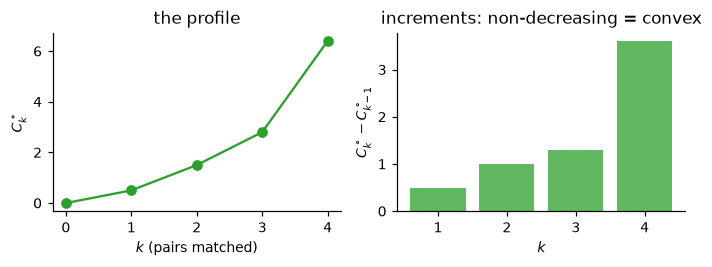

In [4]:
k = np.arange(len(sol.costs))inc = np.diff(sol.costs)fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.4, 2.5))a1.plot(k, sol.costs, "o-", color="tab:green")a1.set_xlabel("$k$ (pairs matched)"); a1.set_ylabel("$C_k^\\circ$")a1.set_title("the profile")a2.bar(k[1:], inc, color="tab:green", alpha=.75)a2.set_xlabel("$k$"); a2.set_ylabel("$C_k^\\circ - C_{k-1}^\\circ$")a2.set_title("increments: non-decreasing = convex")fig.tight_layout()print("increments:", np.round(inc, 3), "-> non-decreasing:", bool(np.all(np.diff(inc) >= -1e-12)))

## 3. The plan at a given $k$`sol.plan(k)` is the $(n, m)$ transport plan: entry $(i,j)$ is `w` if source $i$ is matchedto target $j$, and `0` otherwise.  Exactly $k$ entries are non-zero.

plan at k = 2 (rows = sources, cols = targets):
[[0 0 0 1]
 [0 0 0 0]
 [0 1 0 0]
 [0 0 0 0]]


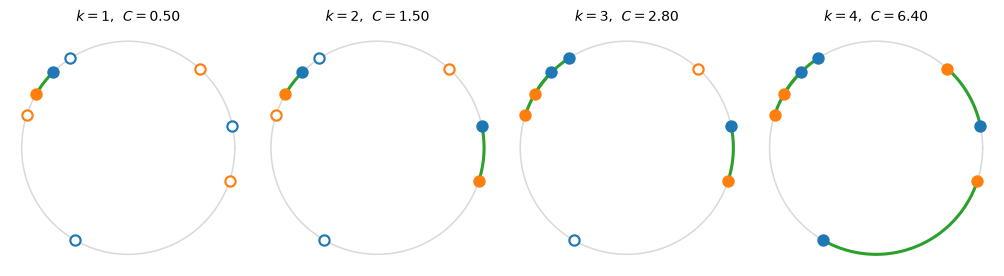

In [5]:
def draw_matching(ax, L, x, y, plan, title):    t = np.linspace(0, 2 * np.pi, 400)    ax.plot(np.cos(t), np.sin(t), color="0.85", lw=1)    ii, jj = np.nonzero(plan)    matched_x, matched_y = set(ii.tolist()), set(jj.tolist())    for pts, c, keep in ((x, "tab:blue", matched_x), (y, "tab:orange", matched_y)):        a = 2 * np.pi * np.asarray(pts) / L        for idx in range(len(pts)):            filled = idx in keep            ax.scatter(np.cos(a[idx]), np.sin(a[idx]), s=45, zorder=3,                       color=c if filled else "white", edgecolor=c, linewidth=1.4)    for i, j in zip(ii, jj):                     # the short way round        a0, a1 = 2 * np.pi * x[i] / L, 2 * np.pi * y[j] / L        d = (a1 - a0 + np.pi) % (2 * np.pi) - np.pi        arc = a0 + np.linspace(0, d, 60)        ax.plot(np.cos(arc) * 1.0, np.sin(arc) * 1.0, color="tab:green", lw=2, zorder=2)    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title, fontsize=9)fig, axes = plt.subplots(1, 4, figsize=(9.2, 2.5))for kk, ax in zip(range(1, 5), axes):    draw_matching(ax, L, x, y, sol.plan(kk), f"$k={kk}$,  $C={sol.costs[kk]:.2f}$")fig.tight_layout()print("plan at k = 2 (rows = sources, cols = targets):")print(sol.plan(2).astype(int))

Filled markers are matched, hollow ones are left alone — that is the "partial" part.  Notethe $k=4$ panel: the arc that wraps across the seam at `0` is the shortest route, and aline solver would have to be told where to cut to find it.## 4. Nested active setsThe sets of matched atoms **grow monotonically**: going from $k$ to $k+1$ adds one sourceand one target and never removes any.  That is what lets one sweep answer every $k$instead of solving $K$ separate problems.

In [6]:
for kk in range(len(sol.costs)):    sx = sorted(int(i) for i in sol.active_x[kk])    sy = sorted(int(j) for j in sol.active_y[kk])    print(f"k={kk}:  sources {str(sx):<16} targets {sy}")grew = all(set(sol.active_x[i]) <= set(sol.active_x[i + 1])           for i in range(len(sol.costs) - 1))print("\nactive sets nested:", grew)

k=0:  sources []               targets []
k=1:  sources [2]              targets [1]
k=2:  sources [0, 2]           targets [1, 3]
k=3:  sources [0, 1, 2]        targets [1, 2, 3]
k=4:  sources [0, 1, 2, 3]     targets [0, 1, 2, 3]

active sets nested: True


The *sets* nest; the *pairing* inside them need not.  An already-matched atom may be handeda different partner as $k$ grows, which is free — re-pairing atoms that are already matchedmoves no new mass.## 5. The simultaneous cutCut the circle at a point and unroll it and you have a line problem.  The catch is that thebest place to cut generally depends on $k$, so the naive method tries all $N$ gaps at everycardinality: $O(N^2\log N)$.PAWC constructs **one** gap $\theta^\star$ that is optimal for *every* $k$ at once, as aby-product of the sweep.  That is what removes the factor of $N$.

In [7]:
theta = sol.cuts[0]print(f"simultaneous cut theta* = {theta:.3f}")print("no atom lies at the cut:", bool(np.all(np.abs(np.concatenate([x, y]) - theta) > 1e-9)))# unrolling at theta* turns every k into a sorted line matchingxs = np.sort((x - theta) % L)ys = np.sort((y - theta) % L)print("\nunrolled sources:", np.round(xs, 2))print("unrolled targets:", np.round(ys, 2))

simultaneous cut theta* = 2.850
no atom lies at the cut: True

unrolled sources: [1.25 1.65 5.15 9.55]
unrolled targets: [ 2.15  2.55  8.55 10.75]


## 6. Choosing $k$Having every $k$ is only useful if you can pick one.  When the amount of genuine mass isknown — "20% of this is clutter" — use it directly.  When it is not, the profile's **elbow**is the usual heuristic: the point where each further pair starts costing sharply more.

16 atoms each, 4 of them clutter; elbow picks k = 12


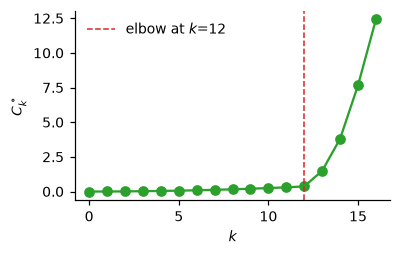

In [8]:
from pawc.elbow import find_elbow# a clearer example: 12 well-matched pairs plus 4 atoms of pure cluttern = 16xs_ = np.sort(rng.uniform(0, L, n))ys_ = (xs_ + rng.normal(0, 0.05, n)) % L          # 12 near-copies ...ys_[-4:] = rng.uniform(0, L, 4)                   # ... and 4 that match nothingys_ = np.sort(ys_)s2 = partial_ot_circle(xs_, ys_, L=L, w=1.0)k_star = find_elbow(s2.costs)fig, ax = plt.subplots(figsize=(3.6, 2.4))ax.plot(np.arange(len(s2.costs)), s2.costs, "o-", color="tab:green")ax.axvline(k_star, color="tab:red", ls="--", lw=1, label=f"elbow at $k$={k_star}")ax.set_xlabel("$k$"); ax.set_ylabel("$C_k^\\circ$"); ax.legend(frameon=False)fig.tight_layout()print(f"{n} atoms each, 4 of them clutter; elbow picks k = {k_star}")

## 7. Why partial, and not balancedThe reason to leave mass unmatched: a **balanced** cost has to move everything, so a littleclutter drags the whole comparison with it.  Below, both measures are the same shape up to arotation, but a fraction of one is replaced by clutter.  We compare the balanced cost($k=K$, matching everything) against a partial one that declines to match the clutter, andask which recovers the true rotation.

clutter 0%:  balanced 0.019   partial 0.019
clutter 10%:  balanced 0.166   partial 0.019
clutter 20%:  balanced 1.734   partial 0.019
clutter 30%:  balanced 2.390   partial 0.019


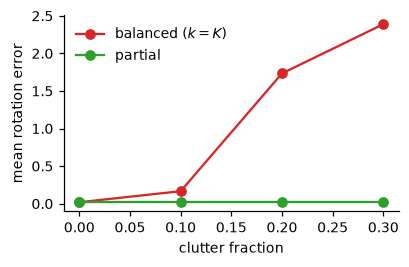

In [9]:
def rotation_error(clutter_frac, n=40, trials=30, rho=None):    """Mean absolute error in recovering a rotation, balanced vs partial."""    bal, par = [], []    keep = int(round((1 - clutter_frac) * n))    for t in range(trials):        r = np.random.default_rng(1000 + t)        base = np.sort(r.uniform(0, L, n))        shift = r.uniform(0, L)        tgt = (base + shift) % L        tgt[keep:] = r.uniform(0, L, n - keep)          # clutter        grid = np.linspace(0, L, 180, endpoint=False)        cb, cp = [], []        for g in grid:            s = partial_ot_circle(np.sort((base + g) % L), np.sort(tgt), L=L, w=1.0)            cb.append(s.costs[-1])                       # balanced: k = K            cp.append(s.costs[keep])                     # partial: match the genuine part        err = lambda c: min(abs(grid[int(np.argmin(c))] - shift),                            L - abs(grid[int(np.argmin(c))] - shift))        bal.append(err(cb)); par.append(err(cp))    return float(np.mean(bal)), float(np.mean(par))fracs = [0.0, 0.1, 0.2, 0.3]res = [rotation_error(f) for f in fracs]bal, par = [r[0] for r in res], [r[1] for r in res]fig, ax = plt.subplots(figsize=(3.8, 2.5))ax.plot(fracs, bal, "o-", color="tab:red", label="balanced ($k=K$)")ax.plot(fracs, par, "o-", color="tab:green", label="partial")ax.set_xlabel("clutter fraction"); ax.set_ylabel("mean rotation error")ax.legend(frameon=False); fig.tight_layout()for f, b, p in zip(fracs, bal, par):    print(f"clutter {f:.0%}:  balanced {b:.3f}   partial {p:.3f}")

With no clutter the two agree — partial transport is not free accuracy, and at $k=K$ it *is*the balanced cost.  As clutter grows the balanced cost degrades while the partial one holds,because it is allowed to ignore the mass that belongs to nothing.## 8. Beyond the circle: the sphereDirectional data in $d$ dimensions lives on $\mathbb{S}^{d-1}$.  Projecting onto greatcircles turns each slice into a circle problem, so PAWC becomes the inner solver of a**sliced spherical partial Wasserstein** discrepancy — and because each slice returns itswhole profile, so does the average.

In [10]:
from pawc.sspw import sample_slices, sspw_profile, sspw_atd, n = 3, 60r = np.random.default_rng(4)X = r.normal(size=(n, d)); X /= np.linalg.norm(X, axis=1, keepdims=True)Y = X + 0.05 * r.normal(size=(n, d))Y[-10:] = r.normal(size=(10, d))                     # 10 outliersY /= np.linalg.norm(Y, axis=1, keepdims=True)slices = sample_slices(d, 64, r)profile = sspw_profile(X, Y, slices, w=1.0 / n)print("SSPW at every transported mass, from one pass over 64 slices")for s in (0.5, 0.8, 1.0):    print(f"  s = {s:.1f} of the mass:  {sspw_at(profile, s, w=1.0/n):.4f}")

SSPW at every transported mass, from one pass over 64 slices
  s = 0.5 of the mass:  0.0059
  s = 0.8 of the mass:  0.0210
  s = 1.0 of the mass:  0.1410


## Where to go next- `demos/demo1_walkthrough.py` — the same worked example, printed step by step.- `demos/demo2_scaling.py` — measured $O(N\log N)$ against the $O(N^2\log N)$ baseline.- `pawc/pawc.py` — the solver itself, pure numpy; `pawc/pawc_numba.py` is the JIT twin.- `pawc/baseline_lp.py`, `pawc/baseline_cuts.py` — the slow, trusted solvers the tests  check against.  If you doubt a result, these are how to settle it.The API in one line:```pythonsol = partial_ot_circle(x, y, L=L, w=w)   # sol.costs, sol.plan(k), sol.active_x, sol.cuts```